In [3]:
import torch

In [18]:
import gzip
import numpy as np

def load_mnist_images(filename):
    """
    从原始的 .gz 压缩包中读取所有图片数据，并返回一个 NumPy 数组。
    """
    with gzip.open(filename, 'rb') as f:
        # 1. 先读取前 16 个字节的头信息
        magic = int.from_bytes(f.read(4), 'big')
        num_images = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        
        print(f"正在读取: {filename}")
        print(f"图片数量: {num_images}, 尺寸: {rows}x{cols}")
        
        # 2. 读取剩下的所有像素数据
        # rows * cols * num_images = 784 * 60000 字节
        buf = f.read(rows * cols * num_images)
        
        # 3. 将二进制流转换为 8 位无符号整数组成的 NumPy 数组
        # 此时它的形状是 (60000, 28, 28)
        data = np.frombuffer(buf, dtype=np.uint8)
        data = data.reshape(num_images, rows, cols)
        return data

def load_mnist_labels(filename):
    """
    从原始的 .gz 压缩包中读取所有标签，并返回一个 NumPy 数组。
    """
    with gzip.open(filename, 'rb') as f:
        # 1. 先读取前 8 个字节的头信息
        magic = int.from_bytes(f.read(4), 'big')
        num_labels = int.from_bytes(f.read(4), 'big')
        
        print(f"正在读取: {filename}")
        print(f"标签数量: {num_labels}")
        
        # 2. 读取剩下的所有标签字节
        buf = f.read(num_labels)
        
        # 3. 转换为 NumPy 数组
        labels = np.frombuffer(buf, dtype=np.uint8)
        return labels

# ==========================================
# 测试我们的读取函数
# ==========================================
if __name__ == "__main__":
    # 填入你那 4 个压缩包所在的真实路径
    # 如果你放在项目下的 data 文件夹里，路径如下：
    train_images_path = './data/MNIST/raw/train-images-idx3-ubyte.gz'
    train_labels_path = './data/MNIST/raw/train-labels-idx1-ubyte.gz'
    
    # 加载测试集 (必须要用模型没见过的数据来测试)
    test_images = load_mnist_images('./data/MNIST/raw/t10k-images-idx3-ubyte.gz')
    test_labels = load_mnist_labels('./data/MNIST/raw/t10k-labels-idx1-ubyte.gz')
    
    # 批量读取 6 万张原始图片和 6 万个标签
    train_images = load_mnist_images(train_images_path)
    train_labels = load_mnist_labels(train_labels_path)
    
    print("\n--- 读取成功！ ---")
    print(f"训练图片数组形状: {train_images.shape} (6万张, 28像素高, 28像素宽)")
    print(f"训练标签数组形状: {train_labels.shape} (6万个标签)")

正在读取: ./data/MNIST/raw/t10k-images-idx3-ubyte.gz
图片数量: 10000, 尺寸: 28x28
正在读取: ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz
标签数量: 10000
正在读取: ./data/MNIST/raw/train-images-idx3-ubyte.gz
图片数量: 60000, 尺寸: 28x28
正在读取: ./data/MNIST/raw/train-labels-idx1-ubyte.gz
标签数量: 60000

--- 读取成功！ ---
训练图片数组形状: (60000, 28, 28) (6万张, 28像素高, 28像素宽)
训练标签数组形状: (60000,) (6万个标签)


第一张图片的真实标签（Label）是: 5

--- 第一张图片的原始像素矩阵 (0 为纯黑，255 为纯白) ---


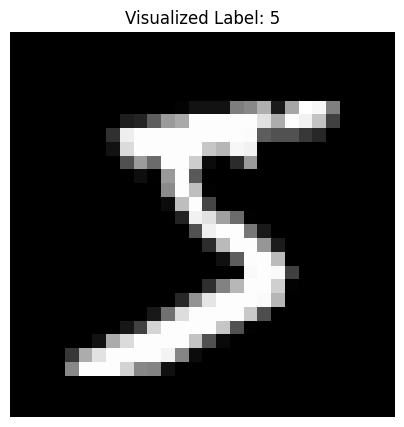

In [5]:
import matplotlib.pyplot as plt
first_image = train_images[0]
first_label = train_labels[0]

print(f"第一张图片的真实标签（Label）是: {first_label}\n")
print("--- 第一张图片的原始像素矩阵 (0 为纯黑，255 为纯白) ---")

'''# 为了能完整看到 28x28 的矩阵，不让 NumPy 用省略号，我们调整一下打印设置
np.set_printoptions(linewidth=150, threshold=1000)
print(first_image)'''

plt.figure(figsize=(5,5))
plt.imshow(first_image,cmap='gray')
plt.title(f"Visualized Label: {first_label}")
plt.axis('off')
plt.show()

In [ ]:
def conv2d_forward(x,weight,bias,stride=1,padding=0):
    '''
    x: the input data (N,C_in,H,W)
    weight: convolution weight (C_out,C_in,K_h, K_w)
    bias: (C_out,)
    '''
    N,C_in,H,W = x.shape
    C_out,_,Kh,Kw = weight.shape
    
    H_out = (H-Kh+2*padding)//stride+1
    W_out = (W-Kw+2*padding)//stride+1
    
    if padding >0:
        x_padded = np.pad(x,((0,0),(0,0),(padding,padding),(padding,padding)),mode='constant')
    else:
        x_padded = x
    
    out = np.zeros((N,C_out,H_out,W_out))
    
    for n in range(N):
        for cout in range(C_out):
            for h in range(H_out):
                for w in range(W_out):
                    h_start = h*stride
                    h_end = h_start+Kh
                    w_start = w*stride
                    w_end = w_start+Kw
                    
                    x_slice = x_padded[n,:,h_start:h_end,w_start:w_end]
                    out[n,cout,h,w] = np.sum(x_slice*weight[cout])+bias[cout]
    return out


def relu_forward(x):
    return np.maximum(0,x)

def maxpool2d_forward(x,kernel_size=2,stride=1):
    N,C,H,W=x.shape
    Kh= Kw=kernel_size
    
    H_out = (H-Kh)//stride+1
    W_out = (W-Kw)//stride+1
    
    out = np.zeros((N,C,H_out,W_out))
    
    for n in range(N):
        for c in range(C):
            for h in range(H_out):
                for w in range(W_out):
                    h_start = h * stride
                    h_end = h_start + Kh
                    w_start = w * stride
                    w_end = w_start + Kw
                    
                    # 提取当前小区域并取最大值
                    x_slice = x[n, c, h_start:h_end, w_start:w_end]
                    out[n, c, h, w] = np.max(x_slice)
    
    return out

def maxpool2d_backward(dout,x,kernel_size = 2,stride=2):
    '''
    dout:(N,C,H_out,W_out)
    x:tensor of input (N,C,H,W)
    '''
    N,C,H,W = x.shape
    Kh=Kw=kernel_size
    _,_,H_out,W_out = dout.shape
    
    dx = np.zeros_like(x)
    for n in range(N):
        for c in range(C):
            for h in range(H_out):
                for w in range(W_out):
                    h_start = h*stride
                    h_end = h_start+Kh
                    w_start = w*stride
                    w_end = w_start+Kw
                    
                    x_slice = x[n,c,h_start:h_end,w_start:w_end]
                    
                    max_idx = np.argmax(x_slice)
                    # 3. 将一维索引还原为二维的 (h_max, w_max)
                    h_max, w_max = np.unravel_index(max_idx, x_slice.shape)
                    
                    dx[n,c,h_start+h_max,w_start+w_max] +=dout[n,c,h,w]
    return dx

def fc_backward(dy,x,w,b):
    '''
    dy:(N,D_out)
    x:(N,D_in)
    w:(D_out,D_in)
    b:(D_out,)
    '''
    dw = np.dot(dy.T,x)
    db = np.sum(dy,axis=0) 
    dx = np.dot(dy,w)
    
    return dx,dw,db

def softmax(x):
    #x:(N,10)
    # 防止指数爆炸：减去行最大值
    shift_x = x - np.max(x, axis=1, keepdims=True)
    exps = np.exp(shift_x)
    return exps / np.sum(exps, axis=1, keepdims=True)

def compute_loss_and_grad(probs, y_true):
    """
    计算交叉熵损失以及对 Logits 的梯度
    """
    N = probs.shape[0]
    # 1. 计算 Loss
    log_probs = -np.log(probs[range(N), y_true] + 1e-8)
    loss = np.sum(log_probs) / N
    
    # 2. 计算对 Softmax 输入层 (Logits) 的梯度: (P - 1)
    dx = probs.copy()
    dx[range(N), y_true] -= 1
    dx /= N
    return loss, dx

def conv2d_backward(dout, x, weight, bias, stride=1, padding=0):
    """
    dout: 上层传回的梯度 (N, C_out, H_out, W_out)
    x: 本层前向传播时的输入 (N, C_in, H, W)
    weight: 卷积核权重 (C_out, C_in, Kh, Kw)
    """
    N, C_in, H, W = x.shape
    C_out, _, Kh, Kw = weight.shape
    _, _, H_out, W_out = dout.shape

    dx = np.zeros_like(x)
    dw = np.zeros_like(weight)
    db = np.zeros_like(bias)

    # 计算 bias 的梯度：直接对输出梯度的 N, H, W 维求和
    db = np.sum(dout, axis=(0, 2, 3))

    # 填充处理
    if padding > 0:
        x_padded = np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant')
        dx_padded = np.pad(dx, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant')
    else:
        x_padded = x
        dx_padded = dx

    for n in range(N):
        for cout in range(C_out):
            for h in range(H_out):
                for w in range(W_out):
                    h_start, w_start = h * stride, w * stride
                    h_end, w_end = h_start + Kh, w_start + Kw
                    
                    # 更新权重的梯度：dout 的一个点对应输入的一个滑窗
                    dw[cout] += x_padded[n, :, h_start:h_end, w_start:w_end] * dout[n, cout, h, w]
                    
                    # 更新输入的梯度：dout 的一个点对应卷积核的权重
                    dx_padded[n, :, h_start:h_end, w_start:w_end] += weight[cout] * dout[n, cout, h, w]

    # 去除 padding 得到原始输入的 dx
    if padding > 0:
        dx = dx_padded[:, :, padding:-padding, padding:-padding]
    else:
        dx = dx_padded

    return dx, dw, db

In [ ]:
import numpy as np

X_train = train_images[:500].reshape(-1,1,28,28)#[number,channel,height,weight]
X_train = X_train.astype(np.float32)/255.0

y_labels = train_labels[:500].astype(np.int32)


# 假设你已经读取了 test_images 和 test_labels
X_test = test_images[:200].reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
y_test = test_labels[:200].astype(np.int32).flatten()
# --- 初始化参数 ---
np.random.seed(42)
lr = 0.01
batch_size = 4  # NumPy手写卷积极慢，建议batch设小
epochs = 10

W_conv = np.random.randn(3, 1, 3, 3) * 0.1
b_conv = np.zeros(3)
print(W_conv)
print(b_conv)

# 经过卷积(26x26)和池化(2x2, stride=2)后，输出为 13x13x3 = 507
W_fc = np.random.randn(10, 507) * 0.1
b_fc = np.zeros(10)

print("开始训练...")

for epoch in range(epochs):
    epoch_loss = 0
    train_correct = 0
    for i in range(0, len(X_train), batch_size):
        x_batch = X_train[i:i+batch_size]
        y_batch = y_labels[i:i+batch_size]

        # 只在第一轮的第一个 batch 打印流动过程
        show_flow = (epoch == 0 and i == 0)

        if show_flow:
            print(f"\n--- 数据流监控 (Batch Size: {batch_size}) ---")
            print(f"输入图片 x_batch: {x_batch.shape}")

        # --- Forward ---
        z_conv = conv2d_forward(x_batch, W_conv, b_conv, padding=0)
        if show_flow: print(f"1. 卷积后 z_conv: {z_conv.shape}")
        
        a_conv = relu_forward(z_conv)
        
        a_pool = maxpool2d_forward(a_conv, kernel_size=2, stride=2)
        if show_flow: print(f"2. 池化后 a_pool: {a_pool.shape}")
        
        N_curr = x_batch.shape[0]
        flat_size = a_pool.shape[1] * a_pool.shape[2] * a_pool.shape[3]
        a_flat = a_pool.reshape(N_curr, flat_size)
        if show_flow: print(f"3. 展平后 a_flat: {a_flat.shape}")
        
        z_fc = np.dot(a_flat, W_fc.T) + b_fc
        probs = softmax(z_fc)
        if show_flow: 
            print(f"4. 输出概率 probs: {probs.shape}")
            print(f"5. 本批次正确标签: {y_batch}")
            print("-" * 30 + "\n")
        
        pres = np.argmax(probs,axis=1)
        train_correct +=np.sum(pres==y_batch)

        # --- Compute Loss & Backward & Update (逻辑保持不变) ---
        loss, dz_fc = compute_loss_and_grad(probs, y_batch)
        epoch_loss += loss
        
        # ... (中间的 Backward 和 Update 代码省略，保持你原来的即可) ...
        da_flat, dW_fc, db_fc = fc_backward(dz_fc, a_flat, W_fc, b_fc)
        da_pool = da_flat.reshape(a_pool.shape)
        da_conv = maxpool2d_backward(da_pool, a_conv, kernel_size=2, stride=2)
        dz_conv = da_conv * (z_conv > 0)
        dx, dW_conv, db_conv = conv2d_backward(dz_conv, x_batch, W_conv, b_conv)
        
        W_fc -= lr * dW_fc
        b_fc -= lr * db_fc
        W_conv -= lr * dW_conv
        b_conv -= lr * db_conv
    acc = train_correct/len(X_train)
    print(f"Epoch{epoch+1}/{epochs}|Loss: {epoch_loss/(len(X_train)/batch_size):.4f} | Train Acc: {acc*100:.2f}%")

    # 计算平均 Loss (总 Loss / 总 batch 数)
    num_batches = len(X_train) // batch_size
    print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {epoch_loss/num_batches:.4f}")

print("训练完成！")

[[[[ 0.04967142 -0.01382643  0.06476885]
   [ 0.15230299 -0.02341534 -0.0234137 ]
   [ 0.15792128  0.07674347 -0.04694744]]]


 [[[ 0.054256   -0.04634177 -0.04657298]
   [ 0.02419623 -0.19132802 -0.17249178]
   [-0.05622875 -0.10128311  0.03142473]]]


 [[[-0.09080241 -0.14123037  0.14656488]
   [-0.02257763  0.00675282 -0.14247482]
   [-0.05443827  0.01109226 -0.11509936]]]]
[0. 0. 0.]
开始训练...

--- 数据流监控 (Batch Size: 4) ---
输入图片 x_batch: (4, 1, 28, 28)
1. 卷积后 z_conv: (4, 3, 26, 26)
2. 池化后 a_pool: (4, 3, 13, 13)
3. 展平后 a_flat: (4, 507)
4. 输出概率 probs: (4, 10)
5. 本批次正确标签: [5 0 4 1]
------------------------------

Epoch1/10|Loss: 2.3107 | Train Acc: 8.00%
Epoch 1/10 | Avg Loss: 2.3107
Epoch2/10|Loss: 2.2963 | Train Acc: 9.60%
Epoch 2/10 | Avg Loss: 2.2963
Epoch3/10|Loss: 2.2803 | Train Acc: 14.00%
Epoch 3/10 | Avg Loss: 2.2803
Epoch4/10|Loss: 2.2104 | Train Acc: 26.20%
Epoch 4/10 | Avg Loss: 2.2104
Epoch5/10|Loss: 1.7179 | Train Acc: 49.60%
Epoch 5/10 | Avg Loss: 1.7179
Epoch6/10|Loss: 0

In [ ]:
print("\n------(Test)----------")
z_conv_t = conv2d_forward(X_test,W_conv,b_conv)
a_conv_t = relu_forward(z_conv_t)
a_pool_t = maxpool2d_forward(a_conv_t,2,2)
a_flat_t = a_pool_t.reshape(X_test.shape[0],-1)
z_fc_t = np.dot(a_flat_t,W_fc.T)+b_fc
probs_t = softmax(z_fc_t)

print(X_test.shape)
test_preds = np.argmax(probs_t,axis=1)
test_acc =np.mean(test_preds==y_test)
print(f"测试集准确率: {test_acc * 100:.2f}%")

# 直观对比前 10 张图
print(f"标准答案: {y_test[:10]}")
print(f"模型预测: {test_preds[:10]}")



------(Test)----------
测试集准确率: 83.00%
标准答案: [7 2 1 0 4 1 4 9 5 9]
模型预测: [7 6 1 0 4 1 4 9 6 7]
